# AI-risk sentiment and AI equities

**Observed window:** September 8-30, 2026. This is a short-window, exploratory event study; Granger tests are predictive-lag diagnostics, not causal identification.

In [1]:
from pathlib import Path
import re, time, xml.etree.ElementTree as ET
from email.utils import parsedate_to_datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from statsmodels.tsa.stattools import grangercausalitytests

START, END = '2026-09-08', '2026-10-01'  # END is exclusive; includes Sep. 30
RAW = Path('data/raw'); RAW.mkdir(parents=True, exist_ok=True)
TICKERS = ['NVDA','META','AMZN','GOOGL','MSFT','AVGO','TSM']
BASKET_LABEL = 'Equal-weight AI basket: NVDA, META, AMZN, GOOGL, MSFT, AVGO, TSM'
HEADERS = {'User-Agent': 'academic event study; contact: student@example.edu'}
print(BASKET_LABEL)

Equal-weight AI basket: NVDA, META, AMZN, GOOGL, MSFT, AVGO, TSM


## 1. Event and data design

The September 8 event is documented by the public X posts quoted in Reuters, BBC, Axios, and Ars Technica (links in the report). Direct X full-archive access was not available, so the quantitative series below is **news-headline tone**, not a claim about all X users. It uses a dated Google News RSS query as an accessible, reproducible coverage sample. The query is capped/ranked by the provider; it is not a census.

The second query is a broad-AI comparison sample. This implements a restrained version of the COVID-paper comparison logic: it tests whether the event-query headlines look more negative than contemporaneous general-AI headlines, not whether "the media" as a whole are biased.

In [2]:
def fetch_rss(label, query):
    path = RAW / f'{label}.xml'
    if path.exists():
        raw = path.read_bytes()
    else:
        url = 'https://news.google.com/rss/search'
        r = requests.get(url, params={'q': query, 'hl':'en-US','gl':'US','ceid':'US:en'}, headers=HEADERS, timeout=30)
        r.raise_for_status(); raw = r.content; path.write_bytes(raw)
        time.sleep(2)
    rows = []
    for item in ET.fromstring(raw).findall('./channel/item'):
        dt = parsedate_to_datetime(item.findtext('pubDate')).date()
        rows.append({'date': pd.Timestamp(dt), 'title': item.findtext('title'), 'link': item.findtext('link'), 'source': (item.find('source').text if item.find('source') is not None else '')})
    return pd.DataFrame(rows)

risk_q = '("Evan Hubinger" OR "Jacob Coxon" OR (Anthropic AND ("AI risk" OR existential OR humanity))) after:2026-09-07 before:2026-10-01'
broad_q = '("artificial intelligence" OR AI) after:2026-09-07 before:2026-10-01'
risk = fetch_rss('risk_query_2026-09-29', risk_q)
broad = fetch_rss('broad_ai_query_2026-09-29', broad_q)
risk = risk.loc[(risk.date >= pd.Timestamp(START)) & (risk.date < pd.Timestamp(END))].copy()
broad = broad.loc[(broad.date >= pd.Timestamp(START)) & (broad.date < pd.Timestamp(END))].copy()
print({'risk-headlines':len(risk), 'broad-AI-headlines':len(broad), 'risk dates': [str(x.date()) for x in sorted(risk.date.unique())]})
risk[['date','title','source']].sort_values('date').head(10)

{'risk-headlines': 56, 'broad-AI-headlines': 99, 'risk dates': ['2026-09-09', '2026-09-10', '2026-09-11', '2026-09-13', '2026-09-14', '2026-09-16', '2026-09-23', '2026-09-29']}


,date,title,source
35,2026-09-09,Ex-Anthropic Researcher Warns AI Threat to Hum...,조선일보
30,2026-09-09,A researcher warned AI could end humanity. Con...,USA Today
3,2026-09-09,Anthropic Researchers Raise Alarm Over A.I. Ac...,The New York Times
4,2026-09-09,Anthropic insiders warn AI could kill all huma...,Axios
5,2026-09-09,Experts weigh in as researcher says AI has mor...,CNBC
24,2026-09-09,Anthropic Worker Quits Over AI Firms ‘Gambling...,bloomberg.com
44,2026-09-09,"AI could kill humanity, warns Anthropic scient...",Firstpost
45,2026-09-09,Anthropic researcher believes more than 10% ch...,BBC
34,2026-09-09,AI researchers 'earnestly believe' it could ki...,CBC
48,2026-09-09,Could AI wipe out humanity in a decade? An Ant...,The Independent


In [3]:
analyzer = SentimentIntensityAnalyzer()
NEG = re.compile(r'\b(risk|risks|danger|dangerous|warning|warns|kill|killing|death|doom|catastroph|existential|threat|fear|panic|alarm|wipe out|humanity)\b', re.I)
POS = re.compile(r'\b(safe|safety|benefit|opportunity|growth|progress|solution|guardrail|optimism|improve)\b', re.I)
def score(df):
    out = df.copy(); out['compound'] = out.title.map(lambda x: analyzer.polarity_scores(x)['compound'])
    out['negative_terms'] = out.title.map(lambda x: len(NEG.findall(x)))
    out['positive_terms'] = out.title.map(lambda x: len(POS.findall(x)))
    out['risk_intensity'] = (out.negative_terms - out.positive_terms) / out.title.str.split().str.len()
    return out
risk, broad = score(risk), score(broad)
comparison = pd.DataFrame({'event/risk query': [risk.compound.mean(), risk.risk_intensity.mean(), len(risk)], 'broad AI query': [broad.compound.mean(), broad.risk_intensity.mean(), len(broad)]}, index=['mean VADER compound','mean risk intensity','headlines'])
comparison


,event/risk query,broad AI query
mean VADER compound,-0.399796,0.014068
mean risk intensity,0.157827,0.010165
headlines,56.000000,99.000000


In [4]:
px = yf.download(TICKERS + ['SPY'], start=START, end=END, auto_adjust=True, progress=False)['Close']
if px.empty: raise RuntimeError('Yahoo Finance returned no prices. Retry later.')
rets = np.log(px).diff().dropna()
rets['basket_return'] = rets[TICKERS].mean(axis=1)
rets['basket_excess_return'] = rets.basket_return - rets['SPY']
calendar = pd.DataFrame(index=rets.index)
daily = risk.groupby('date').agg(headlines=('title','size'), headline_compound=('compound','mean'), risk_intensity=('risk_intensity','mean'))
panel = calendar.join(daily).fillna({'headlines':0,'headline_compound':0,'risk_intensity':0}).join(rets[['basket_return','basket_excess_return']])
print('Trading-day observations:', len(panel))
print('Cumulative basket return: {:.2%}; SPY: {:.2%}'.format(np.exp(rets.basket_return.sum())-1, np.exp(rets.SPY.sum())-1))
panel.round(4)

Trading-day observations: 16
Cumulative basket return: 2.88%; SPY: -0.19%


,headlines,headline_compound,risk_intensity,basket_return,basket_excess_return
Date,,,,,
2026-09-09,10.0,-0.5160,0.1096,-0.0016,0.0031
2026-09-10,2.0,-0.7211,0.1083,-0.0084,-0.0024
2026-09-11,3.0,-0.5356,0.0778,0.0091,0.0006
2026-09-14,4.0,-0.4070,0.1234,-0.0077,-0.0032
2026-09-15,0.0,0.0000,0.0000,-0.0090,-0.0044
2026-09-16,3.0,-0.4607,0.1590,-0.0006,0.0038
2026-09-17,0.0,0.0000,0.0000,0.0200,0.0087
2026-09-18,0.0,0.0000,0.0000,0.0052,0.0039
2026-09-21,0.0,0.0000,0.0000,0.0315,0.0161


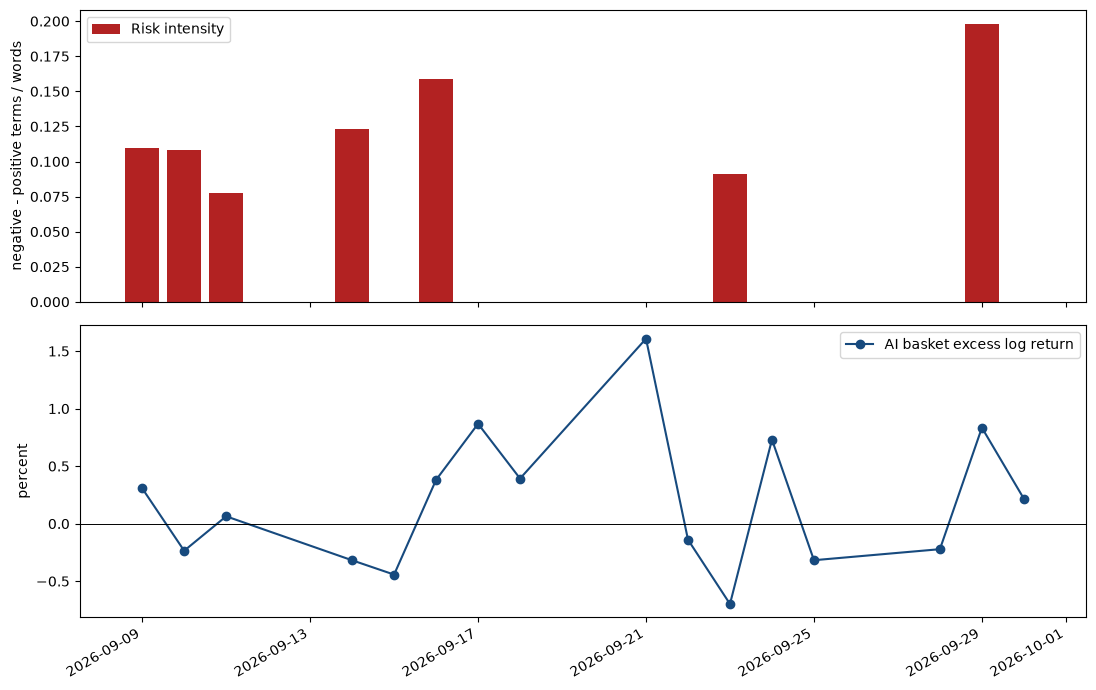

headline_compound -> basket excess return: p=0.6851, usable N=16
risk_intensity -> basket excess return: p=0.9607, usable N=16
headlines -> basket excess return: p=0.8533, usable N=16
Interpretation: one lag leaves very few degrees of freedom. A p-value is not evidence of causal effect; a non-rejection is especially uninformative here.


In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].bar(panel.index, panel.risk_intensity, color='#b22222', label='Risk intensity')
ax[0].axhline(0, color='black', lw=.7); ax[0].legend(); ax[0].set_ylabel('negative - positive terms / words')
ax[1].plot(panel.index, 100*panel.basket_excess_return, marker='o', color='#174a7e', label='AI basket excess log return')
ax[1].axhline(0, color='black', lw=.7); ax[1].legend(); ax[1].set_ylabel('percent'); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

# Null: the second column does NOT improve the first column's one-day-ahead prediction.
def granger_p(data, driver, outcome):
    x = data[[outcome, driver]].dropna()
    result = grangercausalitytests(x, maxlag=1)
    return result[1][0]['ssr_ftest'][1], len(x)
for driver in ['headline_compound','risk_intensity','headlines']:
    p, n = granger_p(panel, driver, 'basket_excess_return')
    print(f'{driver} -> basket excess return: p={p:.4f}, usable N={n}')
print('Interpretation: one lag leaves very few degrees of freedom. A p-value is not evidence of causal effect; a non-rejection is especially uninformative here.')

## Results-based interpretation

### Coverage trend and risk framing

The event/risk query returned **56 headlines**, compared with **99** in the contemporaneous broad-AI query. The difference is substantive in both pre-specified measures: mean VADER compound is **-0.400** for the event/risk sample versus **+0.014** for broad AI, while mean risk intensity is **0.158** versus **0.010**. Thus, the sampled event coverage is decisively more negative and risk-oriented than the broad-AI comparison sample.

The pattern is episodic rather than a smooth deterioration. The original event produces a September 9 burst of 10 sampled headlines, with negative mean tone (-0.516). Covered trading dates remain negative through September 23, including September 10 (-0.721) and September 16 (-0.461). The much larger September 29 cluster belongs to a later Anthropic IPO-risk disclosure story. It should be treated as a separate information shock, not mechanically attributed to the September 8 posts. The September 29 and September 30 trading returns are now included; only September 29 has sampled event-query coverage.

This is evidence of a **risk-framing differential in the sampled headlines**, not proof of general media bias. The event query intentionally selects risk-related material; the RSS provider ranks and caps results; and headlines are not article body text or readership-weighted exposure. The comparison is useful descriptively because it makes the selection rule explicit, but it cannot identify the editorial or audience mechanism behind negative coverage.

### Equity response

For the **16 aligned trading observations** from September 9 through September 30, the equal-weight AI basket compounded **+2.88%**, while SPY compounded **-0.19%**. This positive window-level relative performance coexists with markedly negative event-coverage tone. It therefore does not support a simple narrative in which negative AI-risk discussion persistently reduced the value of the selected AI equities.

Daily performance remains mixed. The basket underperformed SPY on September 10, 14, 15, and 23, but outperformed on September 17, 18, 21, and 24. There is no stable visual correspondence between the covered negative-news days and the sign of the basket's excess return. This is unsurprising: these companies also respond to rates, earnings, chip demand, product developments, and broad risk appetite.

### Predictive-lag diagnostic

The one-lag Granger tests do not reject no incremental predictive content for next-day basket excess return: headline compound sentiment has **p = 0.685**, risk intensity **p = 0.961**, and headline count **p = 0.853**. The appropriate conclusion is narrow: this particular headline-based measure supplies **no detectable one-day-ahead predictive signal** for the basket in the available short sample.

These p-values do not establish that sentiment has no causal effect. The test has only 16 aligned observations, uses bivariate specifications, and assigns zero on a no-coverage day to mean no sampled headline activity - not neutral public sentiment. Granger non-rejection is especially uninformative in a low-power setting. A stronger design would extend the sample, use article bodies and independently sampled social data, and estimate abnormal returns with pre-event market-model controls.


## 2. Reproducibility and limitations

- Inputs are cached as XML in `data/raw/` on first run so the exact sampled titles can be audited; these files are intentionally ignored by Git because feeds change.
- Yahoo Finance adjusted daily closes supply prices; the basket is equal weighted without transaction costs.
- The RSS sample measures published headlines, not article body tone, article readership, retweets, or the complete X/Reddit universe. VADER plus a transparent AI-risk lexicon is a measurement proxy, not human ground truth. VADER plus a transparent AI-risk lexicon is a measurement proxy, not human ground truth.
- 16 sessions are insufficient for credible causal inference. The notebook reports the Granger diagnostic because requested, but the report does not call it proof of causality.